<a href="https://colab.research.google.com/github/tejasrikollati0-create/Population-growth-model-/blob/main/population_growth_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter Young population: 200
Enter Adult population: 100
Enter Old population: 40

Initial population vector:
[200. 100.  40.]
Population transition matrix:
[[0.2 1.5 0.2]
 [0.7 0.6 0. ]
 [0.  0.2 0.8]]
A × population =
[198. 200.  52.]
Eigenvalues:
[-0.63464145  1.46403316  0.77060829]

Dominant eigenvalue:
1.4640331615198805

Dominant eigenvector:
[0.76340536 0.61847597 0.18627864]
Long-term population structure:
Young : 48.68 %
Adult : 39.44 %
Old   : 11.88 %
Population after 20 years:
[316789.30815951 256648.14765864  77299.79205677]


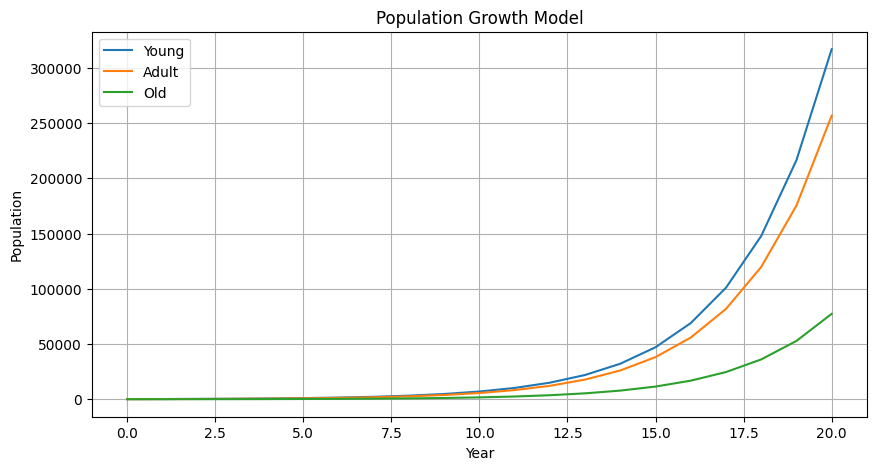

========== RESULTS ==========
Dominant eigenvalue: 1.464
Prediction: Population tends to GROW

Long-term population structure:
Young: 48.68 %
Adult: 39.44 %
Old: 11.88 %


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
young = float(input("Enter Young population: "))
adult = float(input("Enter Adult population: "))
old = float(input("Enter Old population: "))

population = np.array([young, adult, old])

print("\nInitial population vector:")
print(population)
A = np.array([
    [0.2, 1.5, 0.2],
    [0.7, 0.6, 0.0],
    [0.0, 0.2, 0.8]
])

print("Population transition matrix:")
print(A)
next_population = A @ population

print("A × population =")
print(next_population)
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:")
print(eigenvalues)

dominant_index = np.argmax(np.abs(eigenvalues))

dominant_eigenvalue = eigenvalues[dominant_index]
dominant_eigenvector = eigenvectors[:, dominant_index]

print("\nDominant eigenvalue:")
print(dominant_eigenvalue)

print("\nDominant eigenvector:")
print(dominant_eigenvector)
v = np.abs(dominant_eigenvector)

stable_structure = v / np.sum(v)

print("Long-term population structure:")

print("Young :", round(stable_structure[0] * 100, 2), "%")
print("Adult :", round(stable_structure[1] * 100, 2), "%")
print("Old   :", round(stable_structure[2] * 100, 2), "%")
years = 20

history = [population.copy()]

current = population.copy()

for year in range(years):
    current = A @ current
    history.append(current.copy())

history = np.array(history)

print("Population after", years, "years:")
print(history[-1])
plt.figure(figsize=(10, 5))

plt.plot(history[:, 0], label="Young")
plt.plot(history[:, 1], label="Adult")
plt.plot(history[:, 2], label="Old")

plt.xlabel("Year")
plt.ylabel("Population")
plt.title("Population Growth Model")

plt.legend()
plt.grid(True)

plt.show()
print("========== RESULTS ==========")

print("Dominant eigenvalue:",
      round(dominant_eigenvalue.real, 4))

if dominant_eigenvalue.real > 1:
    print("Prediction: Population tends to GROW")
elif dominant_eigenvalue.real < 1:
    print("Prediction: Population tends to DECLINE")
else:
    print("Prediction: Population tends to remain STABLE")

print("\nLong-term population structure:")
print("Young:", round(stable_structure[0] * 100, 2), "%")
print("Adult:", round(stable_structure[1] * 100, 2), "%")
print("Old:", round(stable_structure[2] * 100, 2), "%")